# LSTM Image Classification on CIFAR-10
## Cách 3: Dãy các block/patch làm bước thời gian

**Ý tưởng:** Ảnh CIFAR-10 có kích thước 32×32×3. Ta chia ảnh thành các **block/patch** nhỏ, mỗi patch được flatten thành vector, tạo thành một dãy tuần tự.

**Ví dụ với patch_size = 4×4:**
- Ảnh 32×32 chia thành lưới 8×8 = 64 patches
- Mỗi patch: 4×4×3 = 48 features
- Sequence length = 64 (số patches)
- Input size = 48 (kích thước mỗi patch flatten)

Đây là cách biểu diễn linh hoạt nhất, tương tự ý tưởng của Vision Transformer (ViT).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import os

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Chuẩn bị dữ liệu CIFAR-10

In [2]:
# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = 10
BIDIRECTIONAL = True

# Cách biểu diễn: Patch-wise
IMAGE_SIZE = 32
PATCH_SIZE = 4  # Kích thước mỗi patch (4×4)
NUM_CHANNELS = 3

NUM_PATCHES_PER_DIM = IMAGE_SIZE // PATCH_SIZE  # 32 / 4 = 8
SEQUENCE_LENGTH = NUM_PATCHES_PER_DIM ** 2  # 8 × 8 = 64 patches
INPUT_SIZE = PATCH_SIZE * PATCH_SIZE * NUM_CHANNELS  # 4 × 4 × 3 = 48

print(f'Patch Size: {PATCH_SIZE}×{PATCH_SIZE}')
print(f'Grid: {NUM_PATCHES_PER_DIM}×{NUM_PATCHES_PER_DIM}')
print(f'Sequence Length (num patches): {SEQUENCE_LENGTH}')
print(f'Input Size (patch features): {INPUT_SIZE}')

Patch Size: 4×4
Grid: 8×8
Sequence Length (num patches): 64
Input Size (patch features): 48


In [3]:
# Transform
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Download CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Tên các lớp
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

100%|██████████| 170M/170M [00:04<00:00, 35.2MB/s] 


Training samples: 50000
Test samples: 10000


## 2. Minh họa cách biểu diễn Patch-wise

In [4]:
def image_to_patches(img, patch_size):
    """
    Chuyển ảnh (C, H, W) thành dãy patches theo thứ tự raster (hàng trước).
    Output: (num_patches, patch_size*patch_size*C)
    """
    C, H, W = img.shape
    num_h = H // patch_size
    num_w = W // patch_size
    
    # (C, H, W) -> (C, num_h, patch_size, num_w, patch_size)
    patches = img.reshape(C, num_h, patch_size, num_w, patch_size)
    # -> (num_h, num_w, C, patch_size, patch_size)
    patches = patches.permute(1, 3, 0, 2, 4)
    # -> (num_patches, C * patch_size * patch_size)
    patches = patches.reshape(-1, C * patch_size * patch_size)
    
    return patches  # (64, 48) for 4×4 patches on 32×32×3 image

# Lấy 1 ảnh mẫu
sample_img, sample_label = train_dataset[0]
print(f'Original image shape: {sample_img.shape}')  # (3, 32, 32)

# Chuyển thành patches
patches = image_to_patches(sample_img, PATCH_SIZE)
print(f'Patches shape: {patches.shape}')  # (64, 48)
print(f'  → Sequence length (num patches): {patches.shape[0]}')
print(f'  → Input size (patch features): {patches.shape[1]}')

Original image shape: torch.Size([3, 32, 32])
Patches shape: torch.Size([64, 48])
  → Sequence length (num patches): 64
  → Input size (patch features): 48


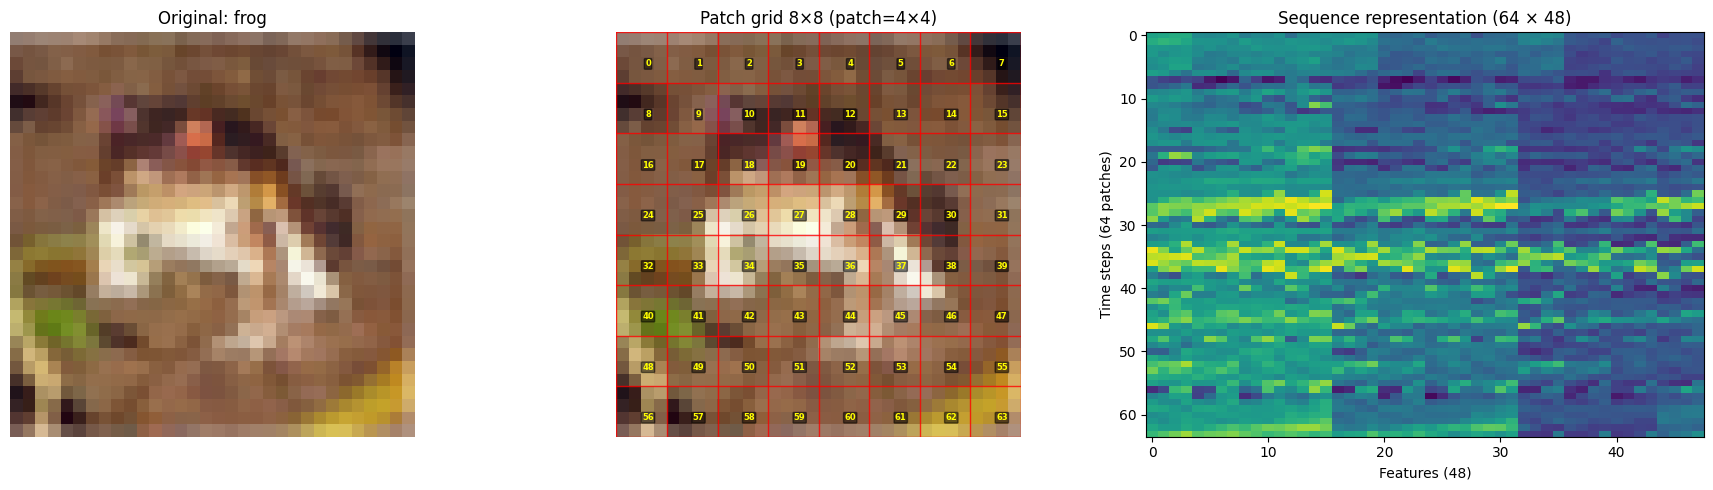

In [5]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ảnh gốc
img_display = sample_img.permute(1, 2, 0).numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
axes[0].imshow(img_display)
axes[0].set_title(f'Original: {classes[sample_label]}')
axes[0].axis('off')

# Hiển thị grid patches
axes[1].imshow(img_display)
for i in range(0, IMAGE_SIZE + 1, PATCH_SIZE):
    axes[1].axhline(y=i-0.5, color='red', linewidth=1.0, alpha=0.8)
    axes[1].axvline(x=i-0.5, color='red', linewidth=1.0, alpha=0.8)
# Đánh số thứ tự patches
for idx in range(SEQUENCE_LENGTH):
    row = idx // NUM_PATCHES_PER_DIM
    col = idx % NUM_PATCHES_PER_DIM
    y = row * PATCH_SIZE + PATCH_SIZE // 2
    x = col * PATCH_SIZE + PATCH_SIZE // 2
    axes[1].text(x, y, str(idx), ha='center', va='center',
                fontsize=6, color='yellow', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
axes[1].set_title(f'Patch grid {NUM_PATCHES_PER_DIM}×{NUM_PATCHES_PER_DIM} '
                  f'(patch={PATCH_SIZE}×{PATCH_SIZE})')
axes[1].axis('off')

# Sequence heatmap
axes[2].imshow(patches.numpy(), aspect='auto', cmap='viridis')
axes[2].set_title(f'Sequence representation ({SEQUENCE_LENGTH} × {INPUT_SIZE})')
axes[2].set_xlabel(f'Features ({INPUT_SIZE})')
axes[2].set_ylabel(f'Time steps ({SEQUENCE_LENGTH} patches)')

plt.tight_layout()
plt.show()

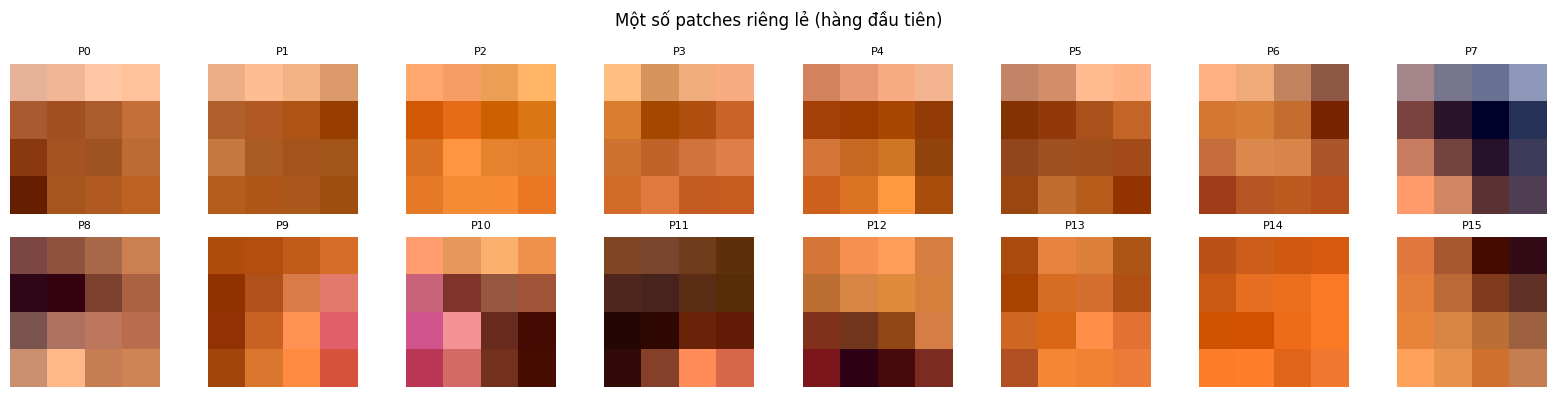

In [6]:
# Hiển thị một số patches riêng lẻ
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Một số patches riêng lẻ (hàng đầu tiên)', fontsize=12)

for i in range(16):
    row = i // 8
    col = i % 8
    # Reshape patch vector thành ảnh nhỏ
    patch_img = patches[i].reshape(NUM_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    patch_img = patch_img.permute(1, 2, 0).numpy()
    patch_img = (patch_img - patch_img.min()) / (patch_img.max() - patch_img.min() + 1e-8)
    
    axes[row, col].imshow(patch_img)
    axes[row, col].set_title(f'P{i}', fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 3. Định nghĩa mô hình LSTM

In [7]:
class LSTM_PatchClassifier(nn.Module):
    """LSTM classifier treating image patches as time steps.
    
    Ảnh được chia thành patches, mỗi patch flatten thành vector.
    Các patches được sắp xếp theo thứ tự raster (hàng trước) tạo thành sequence.
    """
    
    def __init__(self, patch_size, image_size, num_channels, hidden_size, 
                 num_layers, num_classes, bidirectional=True, dropout=0.3):
        super(LSTM_PatchClassifier, self).__init__()
        
        self.patch_size = patch_size
        self.image_size = image_size
        self.num_channels = num_channels
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        self.num_patches_per_dim = image_size // patch_size
        self.num_patches = self.num_patches_per_dim ** 2
        self.input_size = patch_size * patch_size * num_channels
        
        # Patch embedding: linear projection of patches
        self.patch_embed = nn.Sequential(
            nn.Linear(self.input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU()
        )
        
        # Positional encoding (learnable)
        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.num_patches, hidden_size) * 0.02
        )
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention mechanism
        lstm_output_size = hidden_size * self.num_directions
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_output_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch, C=3, H=32, W=32)
        batch_size = x.size(0)
        C, H, W = x.shape[1], x.shape[2], x.shape[3]
        ps = self.patch_size
        num_h = H // ps
        num_w = W // ps
        
        # Tạo patches: (batch, C, H, W) -> (batch, num_patches, patch_features)
        # Step 1: reshape thành grid of patches
        x = x.reshape(batch_size, C, num_h, ps, num_w, ps)
        # Step 2: reorder dimensions
        x = x.permute(0, 2, 4, 1, 3, 5)  # (batch, num_h, num_w, C, ps, ps)
        # Step 3: flatten patches
        x = x.reshape(batch_size, self.num_patches, -1)  # (batch, 64, 48)
        
        # Patch embedding
        x = self.patch_embed(x)  # (batch, 64, hidden_size)
        
        # Add positional encoding
        x = x + self.pos_embedding
        
        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch, num_patches, hidden_size * num_directions)
        
        # Attention
        attn_weights = self.attention(lstm_out)  # (batch, num_patches, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden_size * num_directions)
        
        # Classification
        out = self.classifier(context)
        return out


# Tạo model
model = LSTM_PatchClassifier(
    patch_size=PATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_channels=NUM_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    bidirectional=BIDIRECTIONAL
).to(device)

# In thông tin model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print(model)

Total parameters: 741,899
Trainable parameters: 741,899

LSTM_PatchClassifier(
  (patch_embed): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Huấn luyện mô hình

In [8]:
# Loss và Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Early Stopping
early_stop_patience = 7  # Dừng nếu sau 7 epoch liên tiếp test acc không cải thiện
early_stop_counter = 0

# Training loop
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # ---- Evaluation ----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100. * correct / total
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Scheduler step
    scheduler.step(test_acc)
    
    elapsed = time.time() - start_time
    
    # Save best model + Early Stopping
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_lstm_patch.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | '
          f'Best: {best_acc:.2f}% | Time: {elapsed:.1f}s')
    
    # Early stopping check
    if early_stop_counter >= early_stop_patience:
        print(f'\nEarly stopping at epoch {epoch+1}! No improvement for {early_stop_patience} epochs.')
        break

print(f'\nBest Test Accuracy: {best_acc:.2f}%')

Epoch [1/50] Train Loss: 1.7379 | Train Acc: 34.61% | Test Loss: 1.4954 | Test Acc: 44.55% | Best: 44.55% | Time: 12.0s
Epoch [2/50] Train Loss: 1.3837 | Train Acc: 49.31% | Test Loss: 1.2342 | Test Acc: 54.64% | Best: 54.64% | Time: 10.5s
Epoch [3/50] Train Loss: 1.2019 | Train Acc: 56.82% | Test Loss: 1.0821 | Test Acc: 61.34% | Best: 61.34% | Time: 11.0s
Epoch [4/50] Train Loss: 1.0798 | Train Acc: 61.48% | Test Loss: 1.1068 | Test Acc: 60.48% | Best: 61.34% | Time: 10.7s
Epoch [5/50] Train Loss: 0.9922 | Train Acc: 64.91% | Test Loss: 0.9537 | Test Acc: 65.18% | Best: 65.18% | Time: 10.6s
Epoch [6/50] Train Loss: 0.9208 | Train Acc: 67.32% | Test Loss: 0.8846 | Test Acc: 68.04% | Best: 68.04% | Time: 10.7s
Epoch [7/50] Train Loss: 0.8577 | Train Acc: 69.90% | Test Loss: 0.8586 | Test Acc: 69.76% | Best: 69.76% | Time: 10.8s
Epoch [8/50] Train Loss: 0.8118 | Train Acc: 71.47% | Test Loss: 0.8570 | Test Acc: 69.73% | Best: 69.76% | Time: 10.7s
Epoch [9/50] Train Loss: 0.7716 | Train 

## 5. Visualize kết quả training

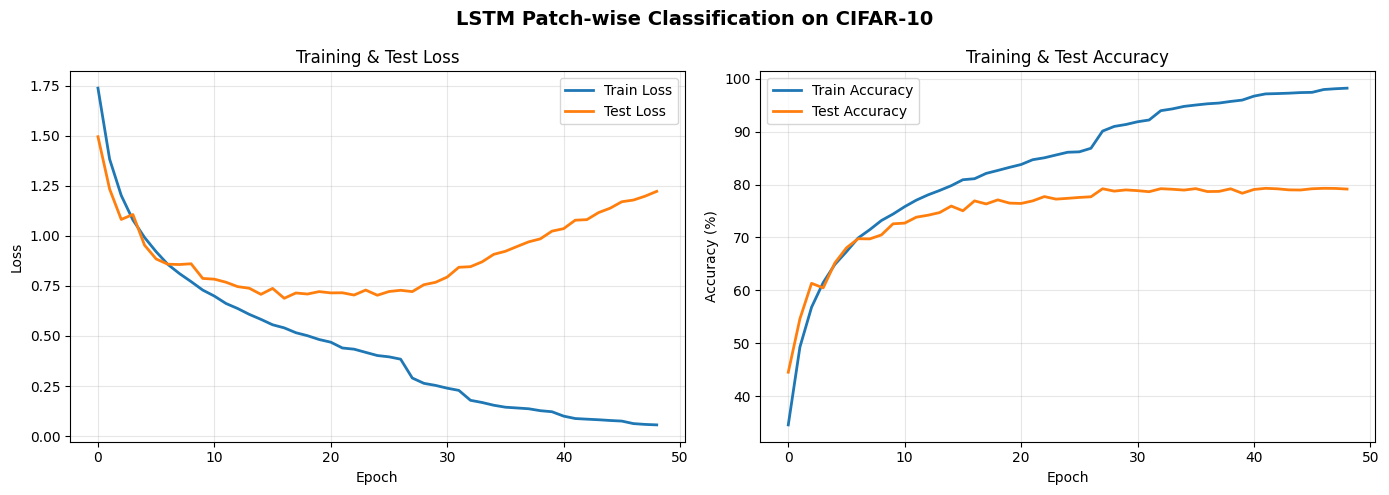

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Patch-wise Classification on CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Đánh giá chi tiết trên tập test

In [10]:
# Load best model
model.load_state_dict(torch.load('best_lstm_patch.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=classes))

=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.82      0.83      0.83      1000
  automobile       0.91      0.89      0.90      1000
        bird       0.74      0.68      0.71      1000
         cat       0.62      0.64      0.63      1000
        deer       0.75      0.77      0.76      1000
         dog       0.72      0.69      0.70      1000
        frog       0.83      0.83      0.83      1000
       horse       0.81      0.83      0.82      1000
        ship       0.87      0.89      0.88      1000
       truck       0.85      0.87      0.86      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



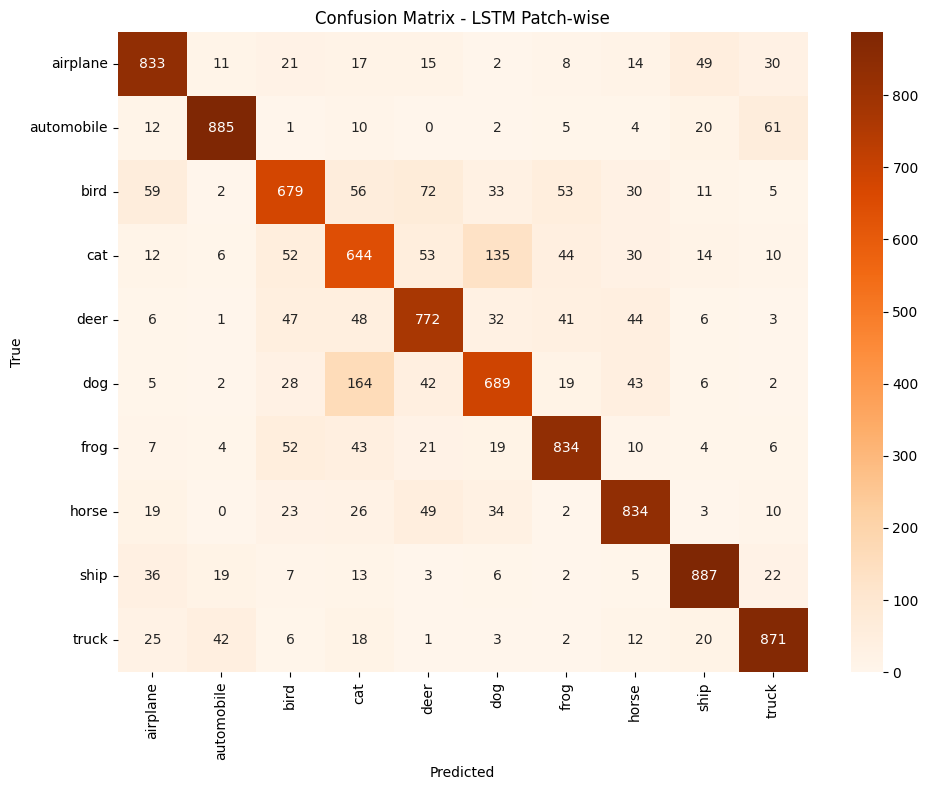

In [11]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM Patch-wise')
plt.tight_layout()
plt.show()

In [12]:
# Accuracy per class
class_correct = {}
class_total = {}
for i in range(NUM_CLASSES):
    mask = all_labels == i
    class_correct[classes[i]] = (all_preds[mask] == i).sum()
    class_total[classes[i]] = mask.sum()

print('\n=== Per-class Accuracy ===')
for cls_name in classes:
    acc = 100. * class_correct[cls_name] / class_total[cls_name]
    print(f'{cls_name:>12s}: {acc:.2f}% ({class_correct[cls_name]}/{class_total[cls_name]})')


=== Per-class Accuracy ===
    airplane: 83.30% (833/1000)
  automobile: 88.50% (885/1000)
        bird: 67.90% (679/1000)
         cat: 64.40% (644/1000)
        deer: 77.20% (772/1000)
         dog: 68.90% (689/1000)
        frog: 83.40% (834/1000)
       horse: 83.40% (834/1000)
        ship: 88.70% (887/1000)
       truck: 87.10% (871/1000)


## 7. Visualize Patch Attention

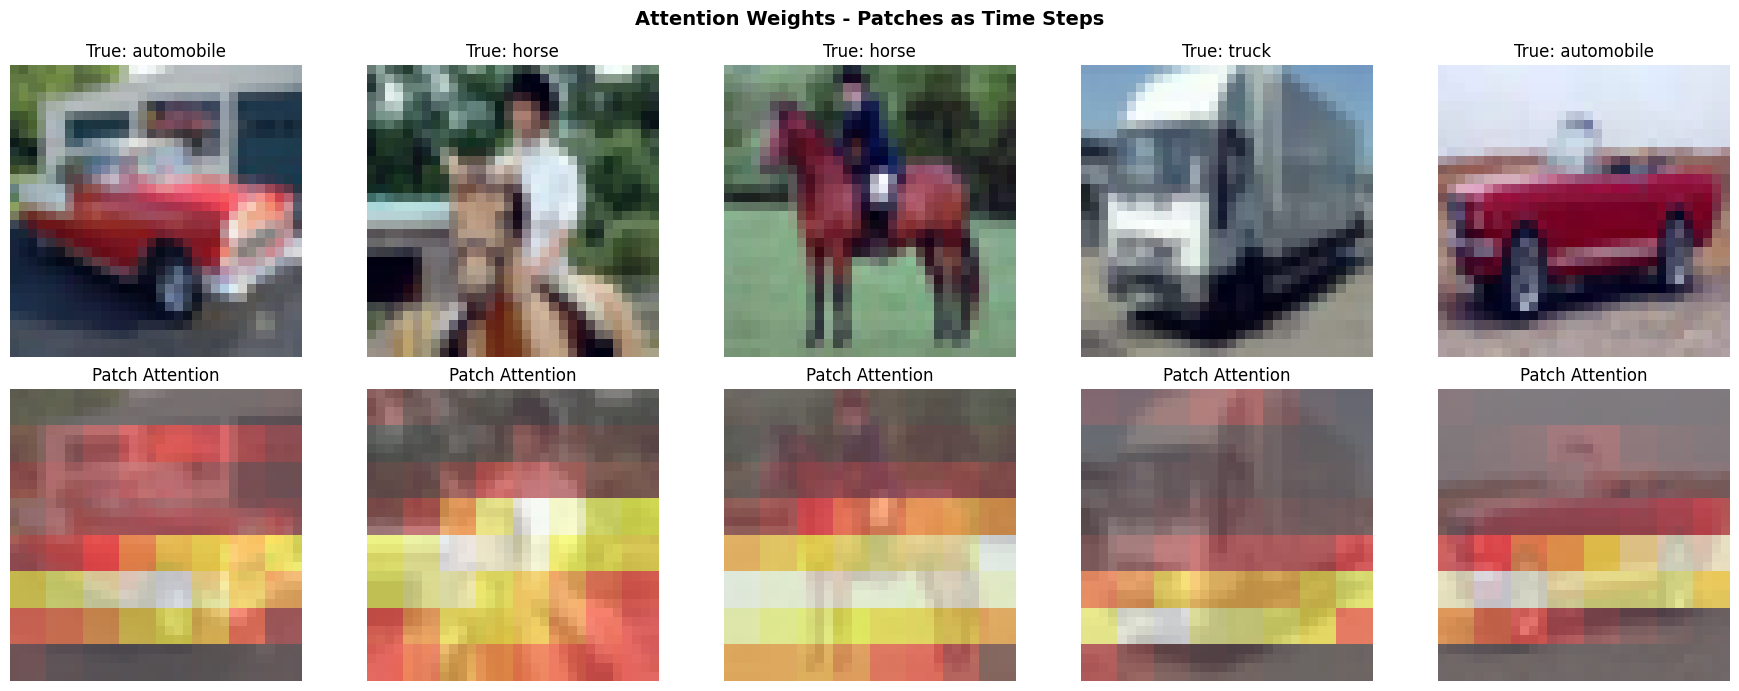

In [13]:
def get_patch_attention(model, image):
    """Trích xuất attention weights trên từng patch."""
    model.eval()
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)  # (1, 3, 32, 32)
        batch_size = x.size(0)
        C, H, W = x.shape[1], x.shape[2], x.shape[3]
        ps = model.patch_size
        num_h = H // ps
        num_w = W // ps
        
        # Tạo patches
        x = x.reshape(batch_size, C, num_h, ps, num_w, ps)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(batch_size, model.num_patches, -1)
        
        # Patch embedding + positional encoding
        x = model.patch_embed(x)
        x = x + model.pos_embedding
        
        # LSTM
        lstm_out, _ = model.lstm(x)
        
        # Attention
        attn_weights = model.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        
        return attn_weights.squeeze().cpu().numpy()

# Visualize attention map
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i in range(5):
    idx = np.random.randint(len(test_dataset))
    img, label = test_dataset[idx]
    attn = get_patch_attention(model, img)
    
    # Ảnh gốc
    img_show = img.permute(1, 2, 0).numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f'True: {classes[label]}')
    axes[0, i].axis('off')
    
    # Attention heatmap trên grid patches
    attn_grid = attn.reshape(NUM_PATCHES_PER_DIM, NUM_PATCHES_PER_DIM)  # (8, 8)
    # Upsample lên kích thước ảnh gốc
    attn_upsampled = np.repeat(np.repeat(attn_grid, PATCH_SIZE, axis=0), PATCH_SIZE, axis=1)
    
    axes[1, i].imshow(img_show, alpha=0.5)
    axes[1, i].imshow(attn_upsampled, cmap='hot', alpha=0.5)
    axes[1, i].set_title('Patch Attention')
    axes[1, i].axis('off')

plt.suptitle('Attention Weights - Patches as Time Steps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Thử nghiệm với các kích thước patch khác nhau

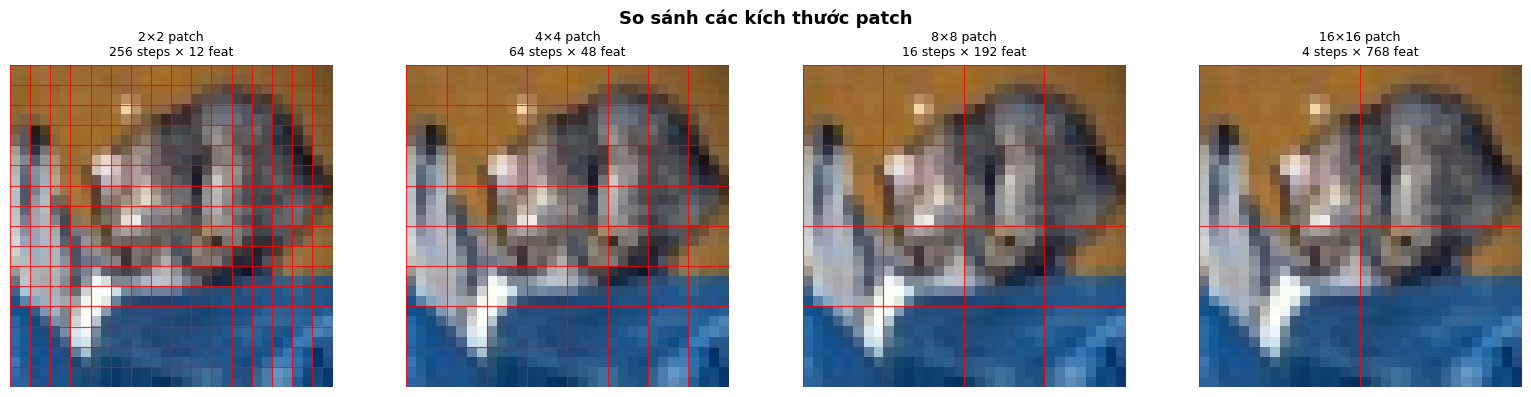

  Patch Size |  Num Patches |  Patch Features | Note
----------------------------------------------------------------------
           2 |          256 |              12 | 2×2 patches → 256 steps × 12 features
           4 |           64 |              48 | 4×4 patches → 64 steps × 48 features
           8 |           16 |             192 | 8×8 patches → 16 steps × 192 features
          16 |            4 |             768 | 16×16 patches → 4 steps × 768 features


In [14]:
# So sánh các cách chia patch
patch_configs = [
    (2, '2×2 patches → 256 steps × 12 features'),
    (4, '4×4 patches → 64 steps × 48 features'),
    (8, '8×8 patches → 16 steps × 192 features'),
    (16, '16×16 patches → 4 steps × 768 features'),
]

sample_img, sample_label = test_dataset[0]
img_display = sample_img.permute(1, 2, 0).numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (ps, desc) in enumerate(patch_configs):
    axes[idx].imshow(img_display)
    for i in range(0, IMAGE_SIZE + 1, ps):
        axes[idx].axhline(y=i-0.5, color='red', linewidth=0.8, alpha=0.8)
        axes[idx].axvline(x=i-0.5, color='red', linewidth=0.8, alpha=0.8)
    
    num_patches = (IMAGE_SIZE // ps) ** 2
    patch_features = ps * ps * 3
    axes[idx].set_title(f'{ps}×{ps} patch\n{num_patches} steps × {patch_features} feat', fontsize=9)
    axes[idx].axis('off')

plt.suptitle('So sánh các kích thước patch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Bảng so sánh
print(f'{"Patch Size":>12} | {"Num Patches":>12} | {"Patch Features":>15} | {"Note"}')
print('-' * 70)
for ps, desc in patch_configs:
    num_p = (IMAGE_SIZE // ps) ** 2
    feat = ps * ps * 3
    print(f'{ps:>12} | {num_p:>12} | {feat:>15} | {desc}')

## 9. Tổng kết

**Cách biểu diễn Patch-wise:**
- **Ưu điểm:** 
  - Linh hoạt nhất: có thể điều chỉnh kích thước patch để cân bằng giữa sequence length và feature dimension.
  - Bảo toàn thông tin spatial cục bộ trong mỗi patch tốt hơn row/column.
  - Tương tự ý tưởng Vision Transformer (ViT), thêm positional encoding giúp LSTM hiểu vị trí không gian.
  - Patch embedding giúp model học biểu diễn tốt hơn cho mỗi patch.
- **Nhược điểm:** 
  - Sequence dài hơn (64 với 4×4 patches vs 32 cho row/column) → tốn bộ nhớ hơn.
  - Cần chọn patch size phù hợp.
- **Trade-offs khi chọn patch size:**
  - Patch nhỏ (2×2): sequence dài (256), features ít (12) → LSTM khó nhớ xa.
  - Patch lớn (16×16): sequence ngắn (4), features nhiều (768) → mất thông tin chi tiết.
  - Patch 4×4 hoặc 8×8 thường cho kết quả tốt nhất.

### So sánh 3 cách biểu diễn:

| Cách | Sequence Length | Input Size | Ưu điểm | Nhược điểm |
| :--- | :---: | :---: | :--- | :--- |
| Row-wise | 32 | 96 | Đơn giản, quét trên-xuống | Mất spatial ngang |
| Column-wise | 32 | 96 | Quét trái-phải | Mất spatial dọc |
| Patch-wise (4×4) | 64 | 48 | Bảo toàn local spatial, linh hoạt | Sequence dài hơn |